# 2nd LEG

## 2.1. Preparing Data

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def prepare_data():
    # 1. Load dataset
    raw_data = load_breast_cancer()
    X, y = raw_data.data, raw_data.target
    
    # 2. Test/Train split (70/30)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 3. Normalization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

# Perform Preparation
X_train, X_test, y_train, y_test = prepare_data()


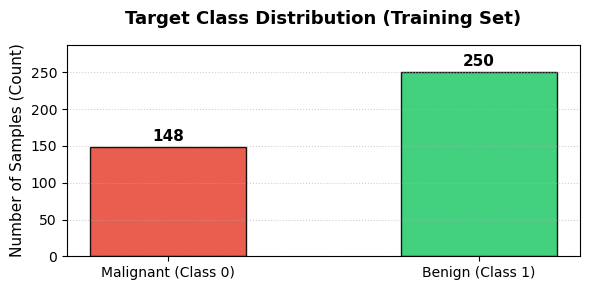

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(y):
    """
    Plots a bar chart showing the distribution of Malignant and Benign classes.
    """
    # Count the occurrences of each class (0 and 1)
    classes, counts = np.unique(y, return_counts=True)
    
    plt.figure(figsize=(6, 3), dpi=100)
    
    # Define colors and labels matching the target meanings
    colors = ['#e74c3c', '#2ecc71']  # Red for Malignant, Green for Benign
    labels = ['Malignant (Class 0)', 'Benign (Class 1)']
    
    # Render the bar chart
    bars = plt.bar(labels, counts, color=colors, edgecolor='k', width=0.5, alpha=0.9)
    
    # Add the exact value numbers on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
                 
    # Customizing layout aesthetics
    plt.ylabel('Number of Samples (Count)', fontsize=11)
    plt.title('Target Class Distribution (Training Set)', fontsize=13, fontweight='bold', pad=15)
    plt.ylim(0, max(counts) * 1.15)  # Give some headroom for the text labels
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# --- Run the Bar Plot using your y_train target variable ---
plot_class_distribution(y_train)

# 2.2 Bias, Variance and Total Error decomposition

Approach: 
    
    1. The data is splitted into 100 different samples (using bootstrap)
    2. Each model makes predictions for the entire test set
    3. The predictions are stored in a 2D matrix (test models vs samples)
Main Prediction: is defnined as the mean of the 100 different samples for each point. If the mean is greater or equal to 0.5 is considered as 1. Otherwise as 0.

Bias: For each point compares the Main Prediction (average) with the ground-truth. Then averages across the different points.

Variance: Compares every single prediction made by every individual model with the main prediction.

The approach was based on the paper:
Dietterich, T.G. and Kong, E.B. (1995) Machine Learning Bias, Statistical Bias, and Statistical Variance of Decision Tree Algorithms. Technical Report, Department of Computer Science, Oregon State University, Corvallis.


PLOT:

ORIGIN: $(0, 0)$ anchors the Ground Truth (actual label). 

Main Prediction displacement: illustrates Bias
Radial dispersion of the Bootstrap Predictions:  model Variance.

In [3]:
from sklearn.utils import resample

def bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=100,show=0):
    """
    Performs manual bootstrapping to estimate Total Error, Bias, and Variance 
    using the 0-1 Loss formulation for classification tasks.
    """
    n_test_samples = len(X_test)
    # Matrix to store predictions: (rows = bootstrap rounds, columns = test samples)
    all_predictions = np.zeros((n_bootstraps, n_test_samples))
    
    # Manual Bootstrap Loop
    for i in range(n_bootstraps):
        # Generate a bootstrap sample from the training set (with replacement)
        X_boot, y_boot = resample(X_train, y_train, random_state=i)
        
        # Train the model on the bootstrap sample and predict on the fixed test set
        model.fit(X_boot, y_boot)
        all_predictions[i, :] = model.predict(X_test)
    
    # --- Statistical Calculations (0-1 Classification Loss) ---
    
    # 1. Total Average Error (proportion of misclassifications across all rounds)
    # Numpy broadcasting compares the (n_bootstraps, n_test) matrix with the (n_test,) y_test vector
    total_error = np.mean(all_predictions != y_test)
    
    # 2. Main Prediction (Majority vote for each test sample across all rounds)
    # Since classes are 0 and 1, a mean >= 0.5 rounded yields the majority class
    main_prediction = np.round(np.mean(all_predictions, axis=0))
    
    # 3. Bias (Proportion of times the Main Prediction differs from the actual ground truth)
    bias = np.mean(main_prediction != y_test)
    
    # 4. Variance (Average deviation of the bootstrap predictions from the Main Prediction)
    variance = np.mean(all_predictions != main_prediction)
    

# --- Visualization Section (The Professional 2x2 Audit Dashboard) ---
    if show == 1:
        import matplotlib.pyplot as plt
        import seaborn as sns
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
        
        # 1. Point-Specific Data (Microscopic view - Sample Index 0)
        sample_idx = 0 
        true_label = y_test[sample_idx]
        main_pred = main_prediction[sample_idx]
        bootstrap_preds = all_predictions[:, sample_idx]
        
        # Metrics for the specific point
        sample_bias = 1.0 if main_pred != true_label else 0.0
        sample_variance = np.mean(bootstrap_preds != main_pred)
        algorithm_name = model.__class__.__name__

        # 2. Global Population Data (Macroscopic view)
        all_sample_variances = np.mean(all_predictions != main_prediction, axis=0)
        all_sample_biases = (main_prediction != y_test).astype(int)

        # --- Create Figure with 2x2 Grid ---
        fig, axes = plt.subplots(1, 2, figsize=(15,10), dpi=100)
        plt.subplots_adjust(hspace=0.35, wspace=0.25)
        (ax1, ax2) = axes # Unpack axes for easier reference


        # =========================================================================
        # PLOT 1 (Bottom-Left): Global Confusion Matrix (Type of Bias)
        # =========================================================================
        cm = confusion_matrix(y_test, main_prediction)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['C0', 'C1'])
        disp.plot(ax=ax1, cmap=plt.cm.Blues, values_format='d', colorbar=False)
        ax1.set_title("3. Global Population: Types of Bias", fontsize=11, fontweight='bold')

        # =========================================================================
        # PLOT 2 (Bottom-Right): Global Variance Profile (Stability Density)
        # =========================================================================
        sns.violinplot(x=all_sample_biases, y=all_sample_variances, ax=ax2, palette=['#5cb85c', '#d9534f'], inner=None, alpha=0.3)
        sns.stripplot(x=all_sample_biases, y=all_sample_variances, ax=ax2, color='#2c3e50', alpha=0.4, size=3, jitter=0.2)
        ax2.set_xticklabels(['Correct (Bias=0)', 'Incorrect (Bias=1)'])
        ax2.set_title("4. Global Population: Variance Distribution", fontsize=11, fontweight='bold')
        ax2.set_ylabel("Variance Rate", fontsize=9)

        # --- Global Title & Analytics Summary ---
        fig.suptitle(f"Bias-Variance Diagnostic Dashboard: {algorithm_name}\nReport for Sample #{sample_idx} vs. Global Population Metrics", 
                     fontsize=15, fontweight='bold', color='#2c3e50', y=0.98)
        
        summary_text = (f"METRICS SUMMARY: [Global Bias: {bias:.3f}] [Global Variance: {variance:.3f}] | "
                        f"[Sample #{sample_idx} Bias: {int(sample_bias)}] [Sample #{sample_idx} Var: {sample_variance:.3f}]")
        fig.text(0.5, 0.02, summary_text, ha='center', fontsize=12, fontweight='bold', 
                 color='#ffffff', bbox=dict(facecolor='#2c3e50', alpha=0.95, boxstyle='round,pad=0.6'))

        plt.show()
    return total_error, bias, variance

# 2.3 How do Bias, Variance, and Total Error vary across different machine learning families under a fixed set of baseline hyperparameters?

It demonstrates the intrinsic "inductive biases" of each method:

 Critical Theoretical Check (0-1 Loss Classification):
 Total Error is calculated empirically from the global misclassification rate. 
 Due to Pedro Domingos' formulation for classification, Total Error is NOT a simple 
 linear sum of global Bias and Variance. Variance can act beneficially (reducing 
 total error) on instances where the main prediction is heavily biased.

Model                          | Total Error  | Bias         | Variance    
---------------------------------------------------------------------------


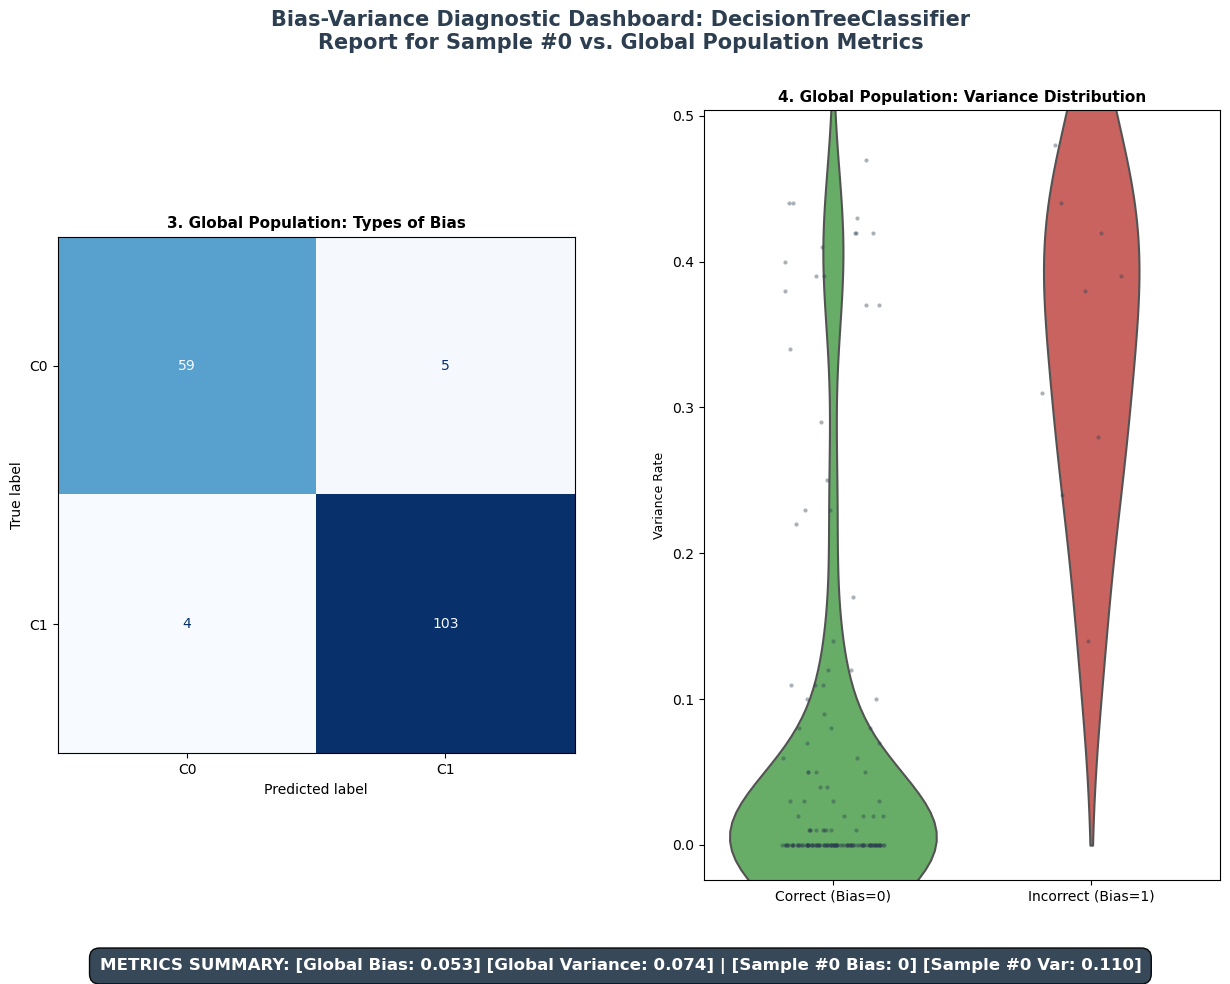

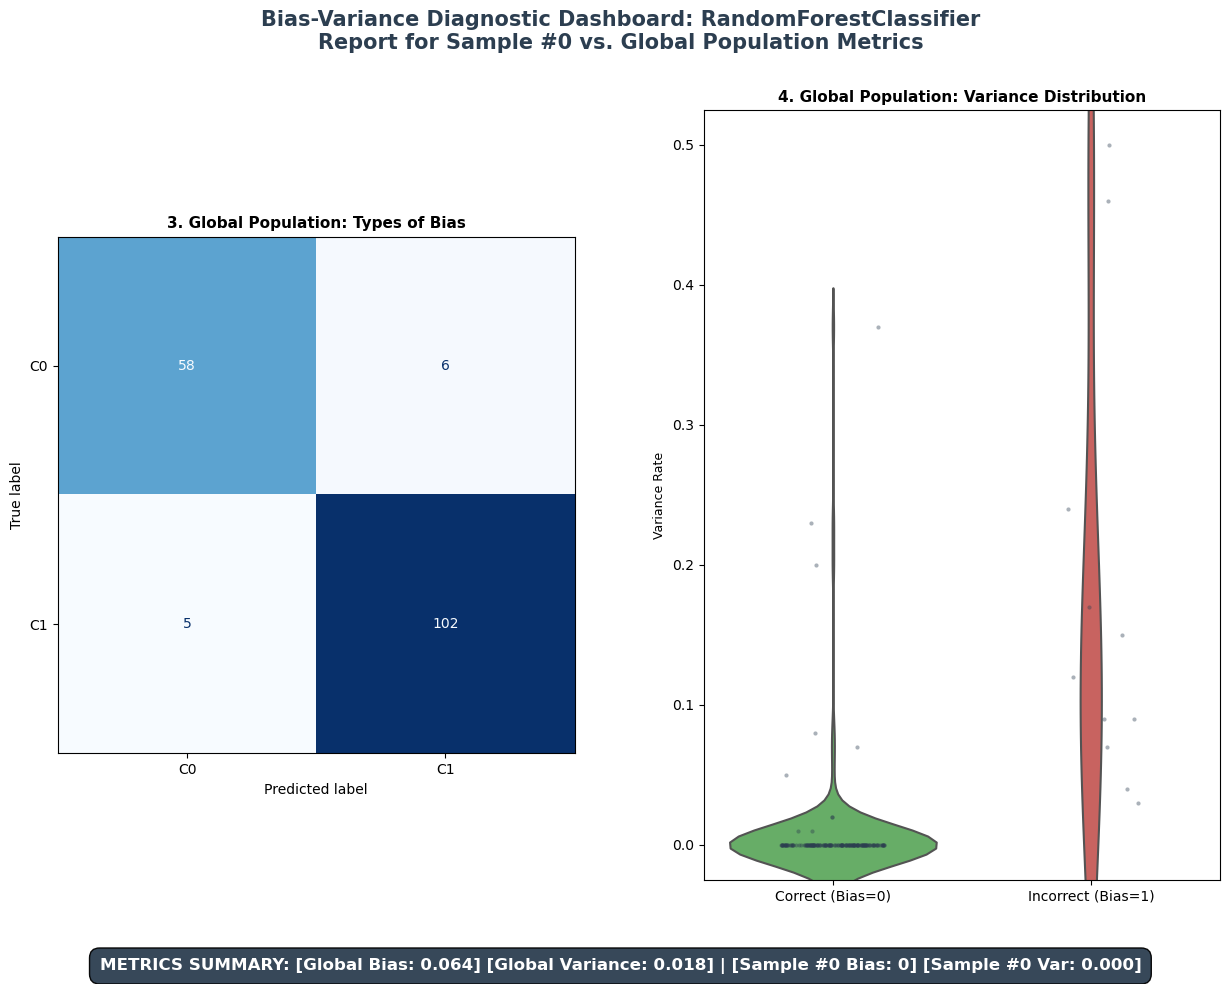

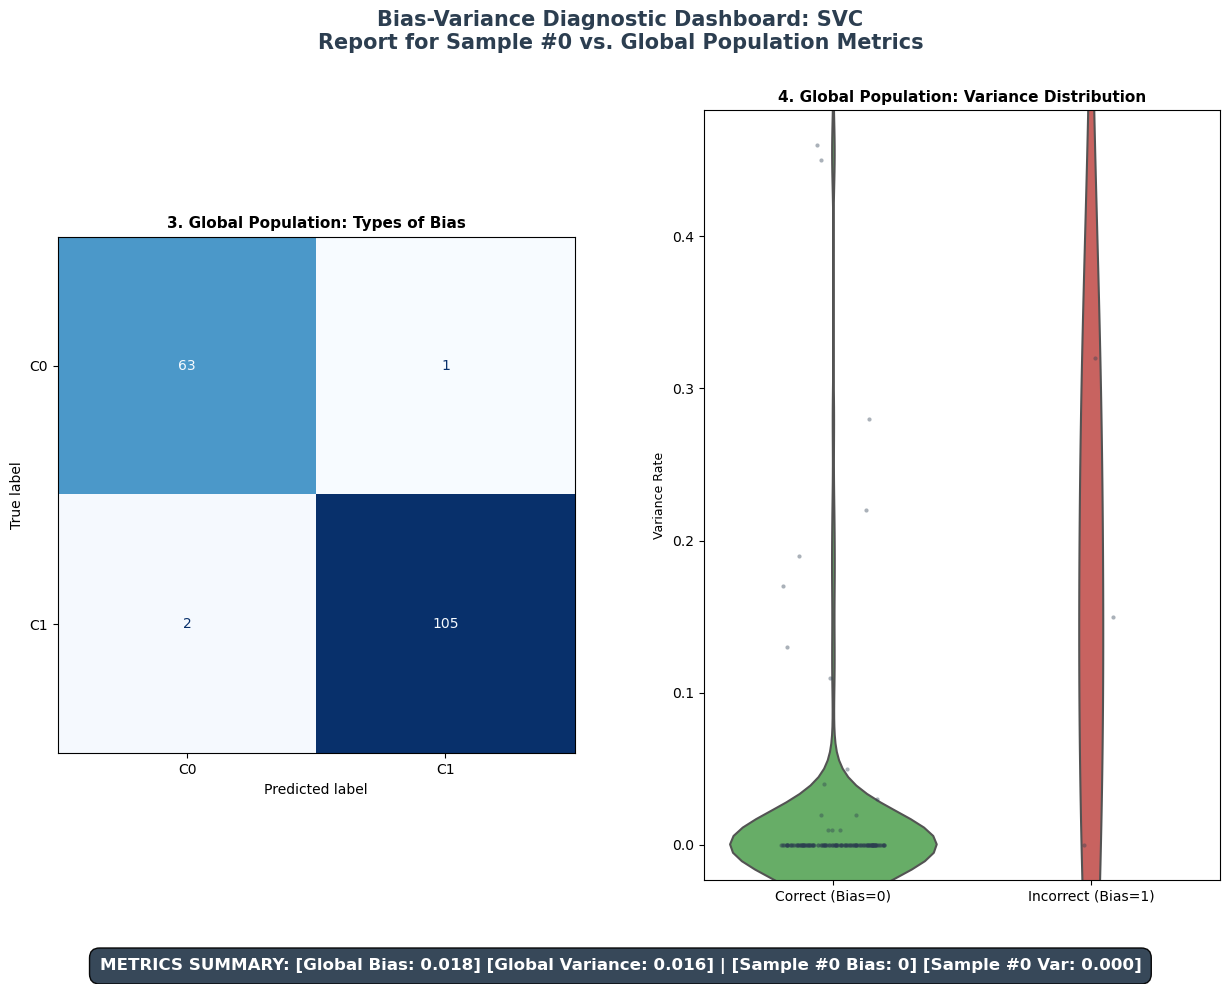

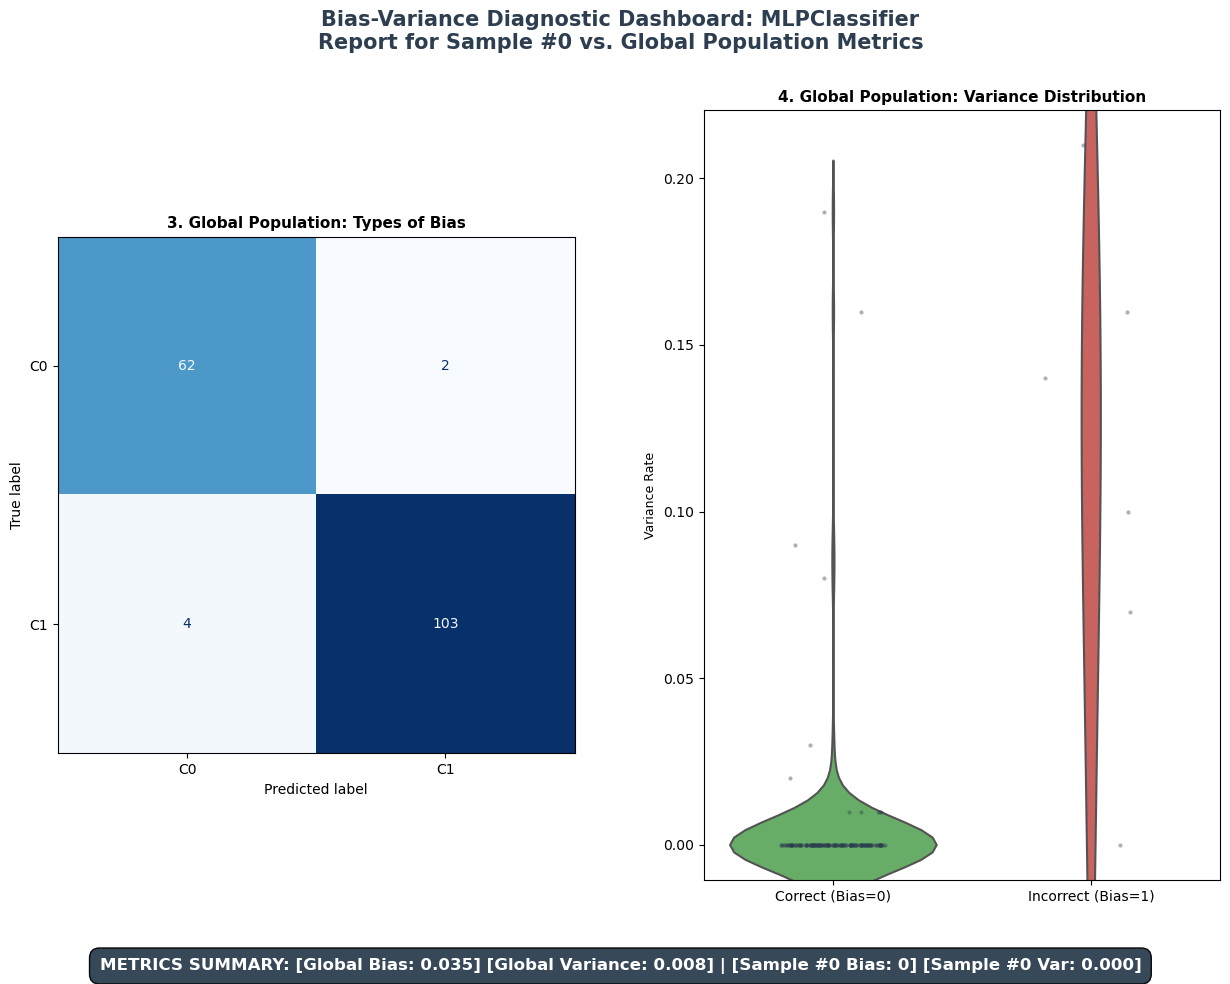

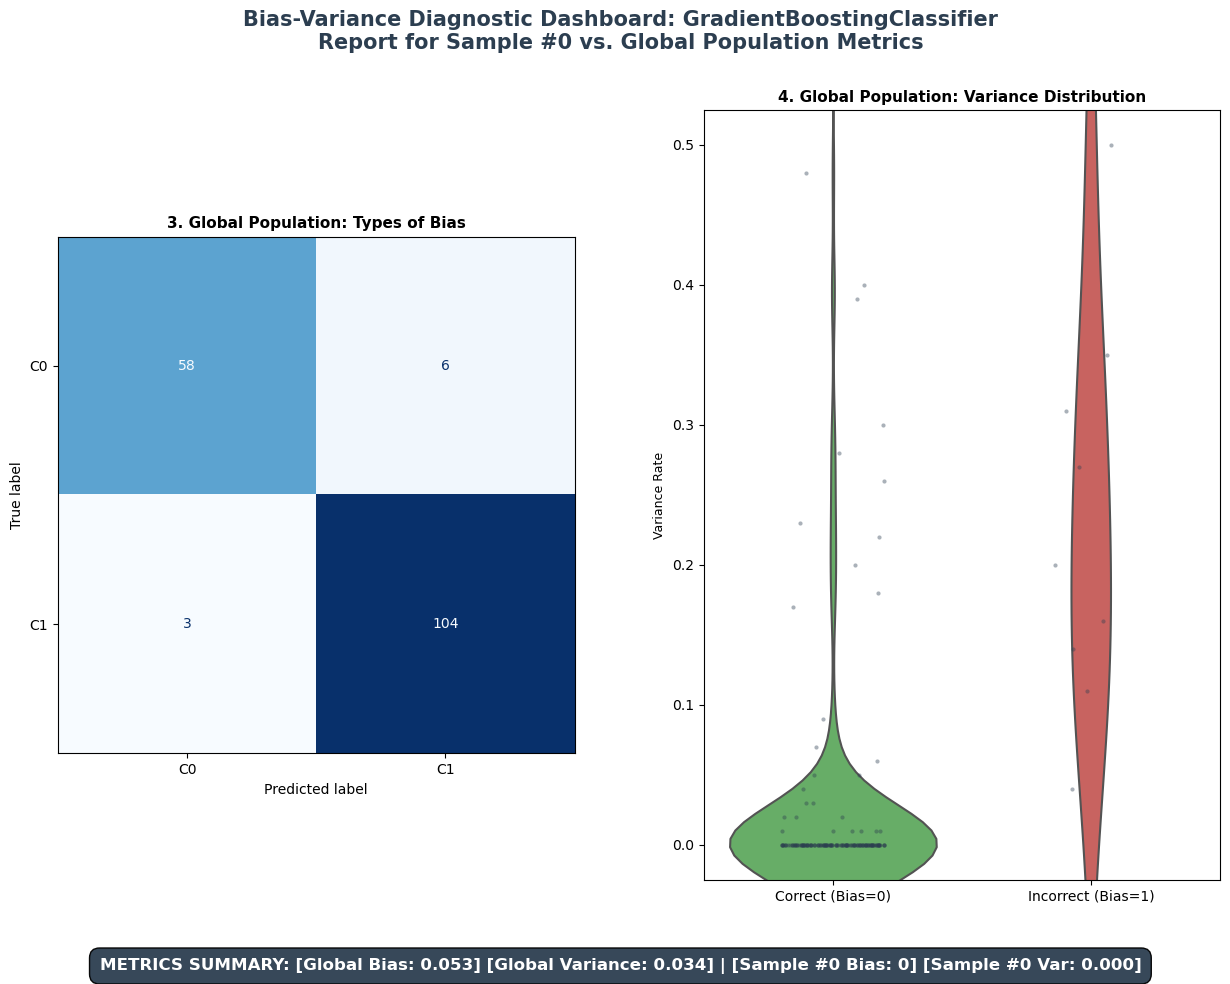

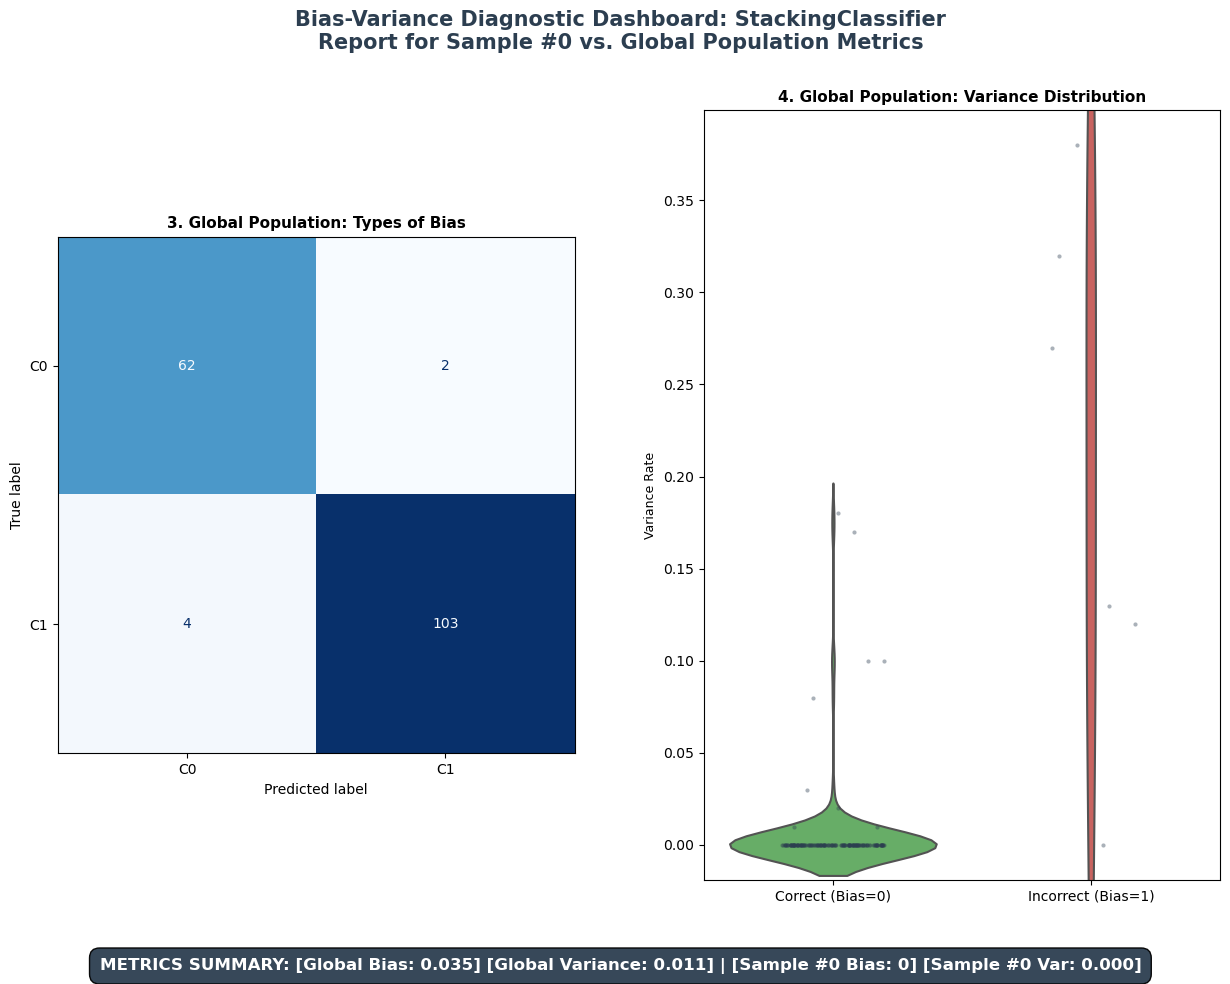

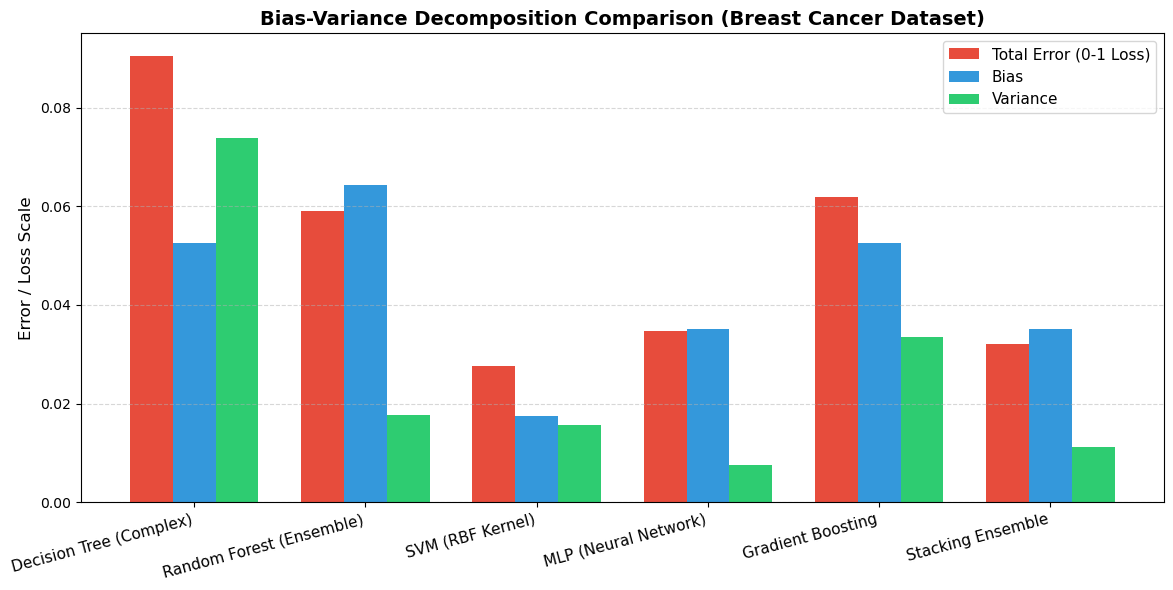

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

def run_and_plot_demonstration(X_train, X_test, y_train, y_test):
    """
    Runs the bootstrap decomposition across different models and plots the results.
    """
    # Define base estimators for stacking
    base_estimators = [
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ('svm', SVC(C=1.0, kernel='rbf', probability=True, random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(30, 30), max_iter=500, random_state=42))
    ]

    # Define models with configurations that highlight their specific properties
    models = {
        "Decision Tree (Complex)": DecisionTreeClassifier(max_depth=None, random_state=42),
        "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM (RBF Kernel)": SVC(C=1.0, kernel='rbf', random_state=42),
        "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(30, 30), max_iter=1000, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
        "Stacking Ensemble": StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(), cv=3)
    }
    
    # Dictionaries to store metrics for plotting
    results = {}
    
    print(f"{'Model':<30} | {'Total Error':<12} | {'Bias':<12} | {'Variance':<12}")
    print("-" * 75)
    
    # Compute metrics using the bootstrap function
    for idx, (model_name, model) in enumerate(models.items()):
        # Track the first model to show its bullseye plot, disable for the rest
        show_plot = 1 if idx == 0 else 1
        
        total_error, bias, variance = bias_variance_decomposition(
            model, X_train, X_test, y_train, y_test, n_bootstraps=100, show=show_plot
        )
        results[model_name] = (total_error, bias, variance)
        #print(f"{model_name:<30} | {total_error:.4f}       | {bias:.4f}       | {variance:.4f}")
        
    # --- Visualization Code ---
    model_names = list(results.keys())
    total_errors = [metrics[0] for metrics in results.values()]
    biases = [metrics[1] for metrics in results.values()]
    variances = [metrics[2] for metrics in results.values()]
    
    # Bar positions and layout configurations
    x_positions = np.arange(len(model_names))
    bar_width = 0.25  
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Render grouped bars for each metric
    ax.bar(x_positions - bar_width, total_errors, bar_width, label='Total Error (0-1 Loss)', color='#e74c3c')
    ax.bar(x_positions, biases, bar_width, label='Bias', color='#3498db')
    ax.bar(x_positions + bar_width, variances, bar_width, label='Variance', color='#2ecc71')
    
    # Customizing plot aesthetics
    ax.set_ylabel('Error / Loss Scale', fontsize=12)
    ax.set_title('Bias-Variance Decomposition Comparison (Breast Cancer Dataset)', fontsize=14, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    return results

# --- Execution ---
# Assumes X_train, X_test, y_train, y_test are already loaded and scaled from Step 1
results = run_and_plot_demonstration(X_train, X_test, y_train, y_test)

# 2.3.1 Expected Properties:

Decision Tree (Unconstrained / Deep)
- Low Bias / High Variance.Reasoning: Without restricting max_depth, a single tree will partition the feature space until it perfectly segregates the training samples (often memorizing noise). When evaluated across different bootstrap samples, its structure changes drastically, leading to high variance.Random 

Random Forest (Ensemble / Bagging)
- Low Bias / Low Variance (Significantly lower variance than the single tree).Reasoning: Bagging builds multiple unconstrained trees in parallel. While each individual tree maintains a low bias, averaging their predictions cancels out the uncorrelated errors, dramatically stabilizing the model and reducing variance.

Support Vector Machine (SVM with RBF Kernel)
- Balanced Bias and Variance (Under default settings).Reasoning: The default $C=1.0$ soft-margin parameter forces a compromise between misclassification and margin maximization. It typically achieves a highly competitive total error by preventing the decision boundary from becoming too wiggly (overfitting) or too rigid (underfitting).

Multi-Layer Perceptron (MLP / Neural Network)
- Moderate Bias / Potential for High Variance.Reasoning: Neural networks are universal approximators. With multiple hidden layers, they have enough capacity to overfit small datasets like Breast Cancer. However, standard implementation defenses (like L2 regularization/weight decay and early stopping) usually keep the variance in check.

# 2.4 How are bias and variance affected by different hyperparameters?

This part of the code aims to highlight how, for each algorithm, the variation of a specific complexity parameter directly impacts the bias and variance of the model.

2.4.0 PLOT

In [5]:

def plot_taming_curves(param_values, total_errors, biases, variances, param_name, model_name, log_scale=False):
    """
    Plots line curves to visualize how changing a hyperparameter tames bias and variance.
    """
    plt.figure(figsize=(8, 4))
    
    # Plot each metric
    plt.plot(param_values, total_errors, label='Total Error', color='#e74c3c', marker='o', linewidth=2.5)
    plt.plot(param_values, biases, label='Bias (Bias^2 equivalent)', color='#3498db', marker='s', linestyle='--')
    plt.plot(param_values, variances, label='Variance', color='#2ecc71', marker='^', linestyle='--')
    
    # Layout and labels
    plt.xlabel(param_name, fontsize=10)
    plt.ylabel('Error / Loss Scale', fontsize=10)
    plt.title(f'Taming Bias & Variance - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=8)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    if log_scale:
        plt.xscale('log')
        
    plt.tight_layout()
    plt.show()

2.4.1 DECISION TREE

Evaluating Decision Tree depths...


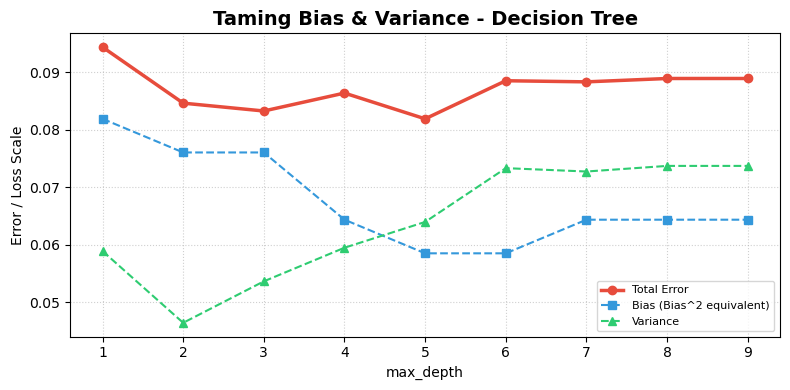

In [6]:
def tame_decision_tree(X_train, X_test, y_train, y_test):
    """
    Evaluates a Decision Tree by varying 'max_depth' to find the optimal trade-off.
    """
    # Test depths from 1 (very simple) to 10 (complex)
    depths = list(range(1, 10))
    total_errors, biases, variances = [], [], []
    
    print("Evaluating Decision Tree depths...")
    for depth in depths:
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        # Using 30 bootstraps to keep execution fast but statistically stable
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Plot the results
    plot_taming_curves(depths, total_errors, biases, variances, 'max_depth', 'Decision Tree')

# Run the taming process for the tree
tame_decision_tree(X_train, X_test, y_train, y_test)

2.4.2 SVM

Evaluating SVM C values...


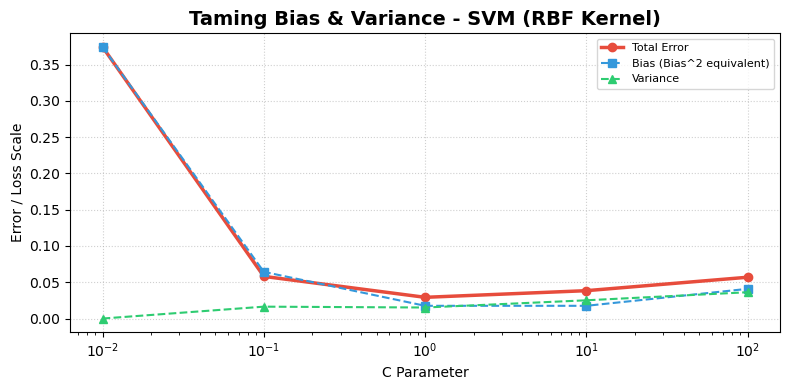

In [7]:
def tame_svm(X_train, X_test, y_train, y_test):
    """
    Evaluates an RBF SVM by varying the regularization parameter 'C'.
    """
    # Test C values on a logarithmic scale
    c_values = [0.01, 0.1, 1, 10, 100]
    total_errors, biases, variances = [], [], []
    
    print("Evaluating SVM C values...")
    for c in c_values:
        model = SVC(C=c, kernel='rbf', random_state=42)
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Plot the results using a log scale on the X axis
    plot_taming_curves(c_values, total_errors, biases, variances, 'C Parameter', 'SVM (RBF Kernel)', log_scale=True)

# Run the taming process for the SVM
tame_svm(X_train, X_test, y_train, y_test)

2.4.3 RANDOM FOREST

Evaluating Random Forest estimators...


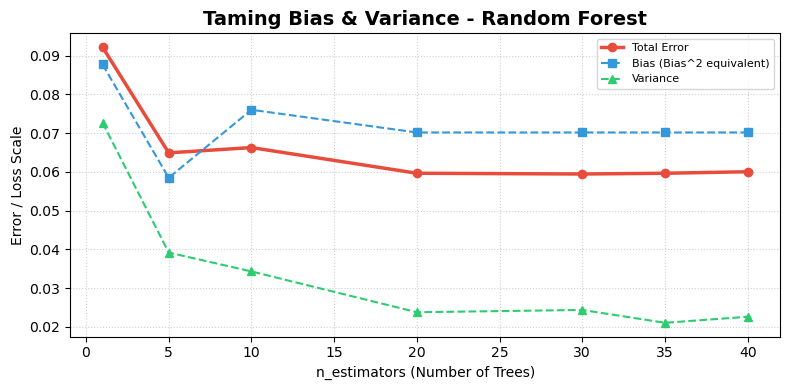

In [8]:
def tame_random_forest(X_train, X_test, y_train, y_test):
    """
    Evaluates a Random Forest by varying 'n_estimators' to demonstrate how 
    ensembling dampens variance.
    """
    # Test from 1 single tree to a small ensemble of 50 trees
    estimator_range = [1, 5, 10, 20, 30,35,40]
    total_errors, biases, variances = [], [], []
    
    print("Evaluating Random Forest estimators...")
    for n_est in estimator_range:
        model = RandomForestClassifier(n_estimators=n_est, random_state=42)
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Plot the results
    plot_taming_curves(estimator_range, total_errors, biases, variances, 'n_estimators (Number of Trees)', 'Random Forest')

# Run the taming process for the forest
tame_random_forest(X_train, X_test, y_train, y_test)

2.4.4 MLP

Evaluating MLP alpha values...


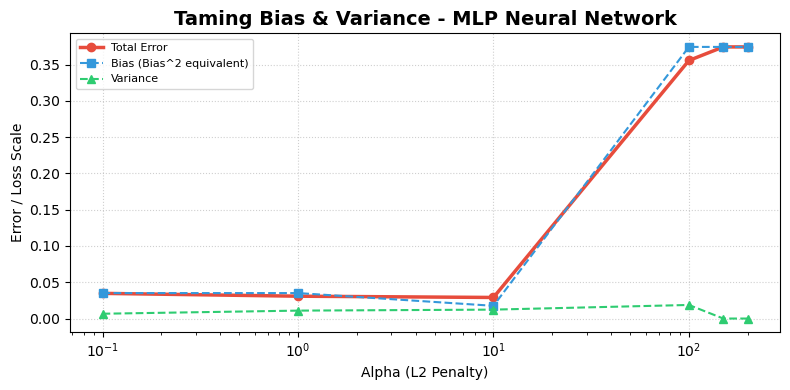

In [9]:
def tame_mlp(X_train, X_test, y_train, y_test):
    """
    Evaluates a Multi-Layer Perceptron by varying the L2 regularization parameter 'alpha'.
    """
    # Test alpha values on a logarithmic scale (from almost no penalty to massive penalty)
    alpha_values = [0.1, 1.0, 10.0, 100.0, 150, 200]
    total_errors, biases, variances = [], [], []
    
    print("Evaluating MLP alpha values...")
    for alpha in alpha_values:
        # Fixed architecture of 30x30 neurons to keep the capacity constant
        model = MLPClassifier(hidden_layer_sizes=(30, 30), alpha=alpha, max_iter=1000, random_state=42)
        err, b, v = bias_variance_decomposition(model, X_train, X_test, y_train, y_test, n_bootstraps=30)
        
        total_errors.append(err)
        biases.append(b)
        variances.append(v)
        
    # Plot the results using a log scale on the X axis
    plot_taming_curves(alpha_values, total_errors, biases, variances, 'Alpha (L2 Penalty)', 'MLP Neural Network', log_scale=True)

# Run the taming process for the MLP
tame_mlp(X_train, X_test, y_train, y_test)

2.4.5 GRADIENT BOOSTING

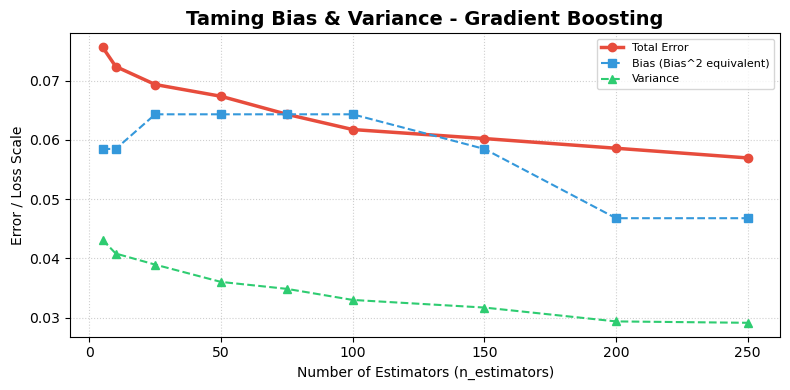

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# =========================================================================
# 1. SIMULAÇÃO PARA GRADIENT BOOSTING (Variando n_estimators)
# =========================================================================
def evaluate_boosting_curve(X_train, X_test, y_train, y_test):
    # Valores de árvores que queremos testar (de muito simples a complexo)
    n_estimators_values = [5, 10, 25, 50,75, 100,150, 200, 250]
    
    total_errors = []
    biases = []
    variances = []
    
    for n in n_estimators_values:
        model = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, random_state=42)
        
        # Usa a tua função original de decomposição (ajusta o nome se necessário)
        total_error, bias, variance = bias_variance_decomposition(
            model, X_train, X_test, y_train, y_test, n_bootstraps=50, show=0
        )
        
        total_errors.append(total_error)
        biases.append(bias)
        variances.append(variance)
        
    # Chama a tua função de plot original
    plot_taming_curves(
        param_values=n_estimators_values, 
        total_errors=total_errors, 
        biases=biases, 
        variances=variances, 
        param_name="Number of Estimators (n_estimators)", 
        model_name="Gradient Boosting", 
        log_scale=False
    )

evaluate_boosting_curve(X_train, X_test, y_train, y_test)

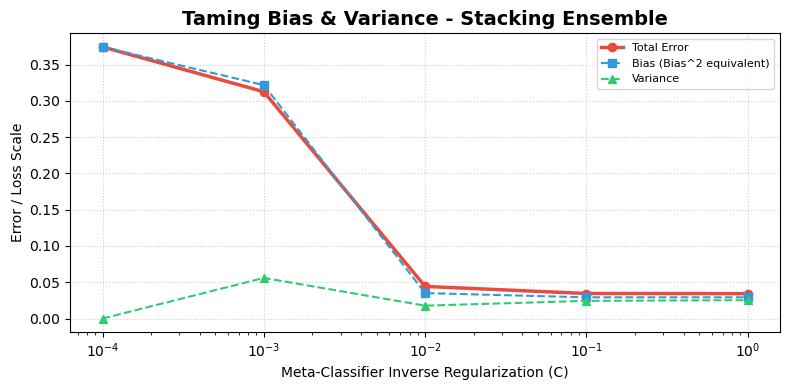

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
# =========================================================================
# 2. SIMULAÇÃO PARA STACKING (Variando a regularização C do Meta-Modelo)
# =========================================================================
def evaluate_stacking_curve(X_train, X_test, y_train, y_test):
    # Valores de C para a Regressão Logística final (Escala Logarítmica)
    # C pequeno = Muita regularização (Simplifica o Stacking)
    # C grande = Nenhuma regularização (Complexifica o Stacking)
    c_values = [0.0001, 0.001, 0.01, 0.1, 1.0]
    
    total_errors = []
    biases = []
    variances = []
    
    # Modelos base fixos para o Stacking
    base_estimators = [
        ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
        ('svm', SVC(C=1.0, kernel='rbf', random_state=42))
    ]
    
    for c in c_values:
        # Variamos o C no final_estimator
        model = StackingClassifier(
            estimators=base_estimators,
            final_estimator=LogisticRegression(C=c, max_iter=1000, random_state=42),
            cv=3
        )
        
        total_error, bias, variance = bias_variance_decomposition(
            model, X_train, X_test, y_train, y_test, n_bootstraps=30, show=0
        )
        
        total_errors.append(total_error)
        biases.append(bias)
        variances.append(variance)
        
    # Chama a tua função de plot original (ativando log_scale=True para o parâmetro C)
    plot_taming_curves(
        param_values=c_values, 
        total_errors=total_errors, 
        biases=biases, 
        variances=variances, 
        param_name="Meta-Classifier Inverse Regularization (C)", 
        model_name="Stacking Ensemble", 
        log_scale=True
    )
evaluate_stacking_curve(X_train, X_test, y_train, y_test)

Using bagging method to improve variance 

According to the paper mentioned before, this approach can help to improve variance.

In [12]:
import numpy as np
from sklearn.utils import resample
from sklearn.ensemble import BaggingClassifier

def bias_variance_decomposition_bagging(model, X_train, X_test, y_train, y_test, n_bootstraps=100):
    """
    Performs manual bootstrapping to estimate Total Error, Bias, and Variance
    of a BAGGING ENSEMBLE of the target model.
    """
    n_test_samples = len(X_test)
    all_predictions = np.zeros((n_bootstraps, n_test_samples))
    
    for i in range(n_bootstraps):
        X_boot, y_boot = resample(X_train, y_train, random_state=i)
        
        # Criamos o ensemble Bagging do modelo base para esta rodada
        # n_estimators=10 garante rapidez no loop sem perder o efeito estatístico
        # Altera de estimator=model para base_estimator=model
        bagging_ensemble = BaggingClassifier(base_estimator=model, n_estimators=10, random_state=i)
        
        bagging_ensemble.fit(X_boot, y_boot)
        all_predictions[i, :] = bagging_ensemble.predict(X_test)
    
    # Cálculos Estatísticos Uniformes (0-1 Loss)
    total_error = np.mean(all_predictions != y_test)
    main_prediction = np.round(np.mean(all_predictions, axis=0))
    bias = np.mean(main_prediction != y_test)
    variance = np.mean(all_predictions != main_prediction)
    
    return total_error, bias, variance

In [13]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

def run_bagging_table_comparison(X_train, X_test, y_train, y_test, results_single):
    """
    Receives previous 6-model bootstrap results, computes bagging results for valid targets,
    and returns a clean comparative Pandas DataFrame.
    """
    # Define only the models where applying a Bagging meta-estimator makes scientific sense
    target_models = {
        "Decision Tree (Complex)": DecisionTreeClassifier(max_depth=None, random_state=42),
        "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(30, 30), max_iter=1000, random_state=42)
    }
    
    table_data = []
    
    print("Computing Bagging Ensembles for selected models (reusing single results)...")
    
    for model_name, model in target_models.items():
        # 1. Safely extract pre-computed metrics from your exact 'results' dictionary keys
        total_error_s, bias_s, variance_s = results_single[model_name]
        
        # 2. Compute metrics for the Bagging architecture wrapper
        total_error_b, bias_b, variance_b = bias_variance_decomposition_bagging(
            model, X_train, X_test, y_train, y_test, n_bootstraps=100
        )
        
        # 3. Append the formatted results side by side
        table_data.append({
            "Target Algorithm": model_name,
            "Single: Total Error": f"{total_error_s:.4f}",
            "Single: Bias": f"{bias_s:.4f}",
            "Single: Variance": f"{variance_s:.4f}",
            "Bagging: Total Error": f"{total_error_b:.4f}",
            "Bagging: Bias": f"{bias_b:.4f}",
            "Bagging: Variance": f"{variance_b:.4f}"
        })
        
    # Convert to Pandas DataFrame for crisp HTML display in the Notebook
    df_comparison = pd.DataFrame(table_data).set_index("Target Algorithm")
    
    return df_comparison

# --- Notebook Execution ---
# Pass your exact 'results' variable generated by run_and_plot_demonstration
df_final = run_bagging_table_comparison(X_train, X_test, y_train, y_test, results_single=results)
df_final

Computing Bagging Ensembles for selected models (reusing single results)...


,Single: Total Error,Single: Bias,Single: Variance,Bagging: Total Error,Bagging: Bias,Bagging: Variance
Target Algorithm,,,,,,
Decision Tree (Complex),0.0906,0.0526,0.0740,0.0719,0.0643,0.0486
MLP (Neural Network),0.0347,0.0351,0.0076,0.0306,0.0292,0.0138
